<a href="https://colab.research.google.com/github/DivyaSS309/Advanced-Computing-and-ML-Project/blob/main/Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.metrics import average_precision_score

# Q1. Sourcing the Dataset

In [ ]:
# Loading the dataset (on Google Colab)

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/fraudTrain.csv')
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [ ]:
dftest = pd.read_csv('/content/drive/MyDrive/fraudTest.csv')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Q2. Data Exploration and Visualtion

In [ ]:
df.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,6.483370e+05,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,3.743180e+05,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,3.241685e+05,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,6.483370e+05,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,9.725055e+05,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,1.296674e+06,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

The data shows no missing values

In [ ]:
# Check how amount is distributed

df['amt'].describe()

,amt
count,1.296675e+06
mean,7.035104e+01
std,1.603160e+02
min,1.000000e+00
25%,9.650000e+00
50%,4.752000e+01
75%,8.314000e+01
max,2.894890e+04


In [ ]:
# Total # of fraudulent transactions

df.is_fraud.value_counts()

,count
is_fraud,
0,1289169
1,7506


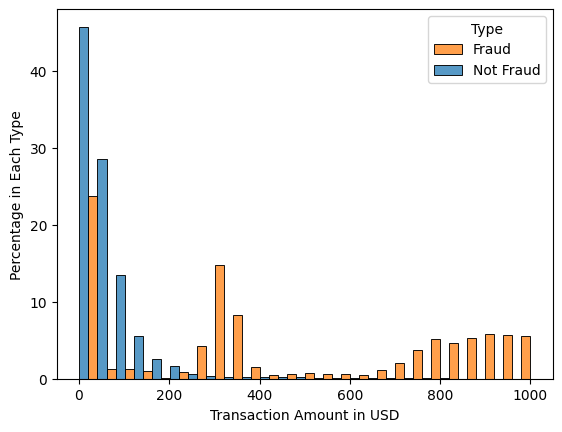

In [ ]:
# Amount vs fraud

ax=sns.histplot(x='amt',data=df[df.amt<=1000],hue='is_fraud',stat='percent',multiple='dodge',common_norm=False,bins=25)
ax.set_ylabel('Percentage in Each Type')
ax.set_xlabel('Transaction Amount in USD')
plt.legend(title='Type', labels=['Fraud', 'Not Fraud'])

The result is very interesting!
* Normal transactions tend to be around USD 200 or less
* Fraudulent transactions peak around USD 300 and then at the USD 800-1000 range. There are also a lot of small dollar value fradulent transactions

Text(0.5, 1.0, 'The Percentage Difference of Fraudulent over Non-Fraudulent Transations in Each Spending Category ')

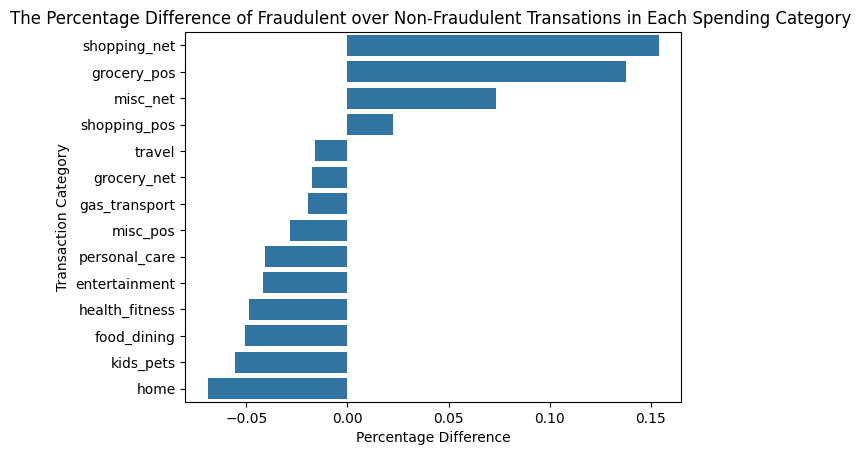

In [ ]:
# Spending category vs fraud

#calculate the percentage difference
a=df[df['is_fraud']==0]['category'].value_counts(normalize=True).to_frame().reset_index()
a.columns=['category','not fraud percentage']

b=df[df['is_fraud']==1]['category'].value_counts(normalize=True).to_frame().reset_index()
b.columns=['category','fraud percentage']
ab=a.merge(b,on='category')
ab['diff']=ab['fraud percentage']-ab['not fraud percentage']

ax=sns.barplot(y='category',x='diff',data=ab.sort_values('diff',ascending=False))
ax.set_xlabel('Percentage Difference')
ax.set_ylabel('Transaction Category')
plt.title('The Percentage Difference of Fraudulent over Non-Fraudulent Transations in Each Spending Category ')

Some spending categories see more fraud than others! Fraud tends to happen more often in 'Shopping_net', 'Grocery_pos', and 'Misc_net'

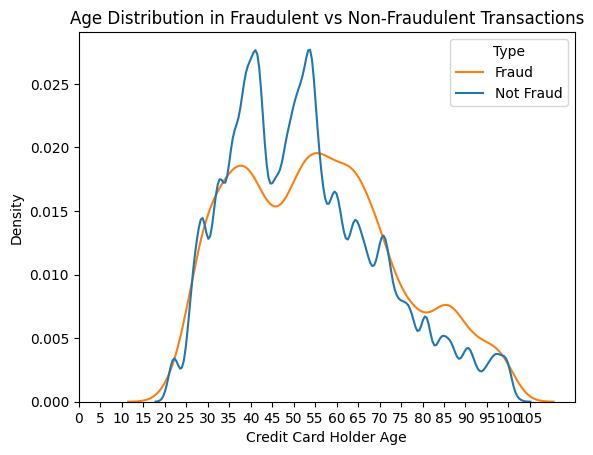

In [ ]:
# Has age got anything to do with it?

import datetime as dt
df['age']=dt.date.today().year-pd.to_datetime(df['dob']).dt.year
dftest['age']=dt.date.today().year-pd.to_datetime(dftest['dob']).dt.year

ax=sns.kdeplot(x='age',data=df, hue='is_fraud', common_norm=False)
ax.set_xlabel('Credit Card Holder Age')
ax.set_ylabel('Density')
plt.xticks(np.arange(0,110,5))
plt.title('Age Distribution in Fraudulent vs Non-Fraudulent Transactions')
plt.legend(title='Type', labels=['Fraud', 'Not Fraud'])

The age distribution is visibly different between 2 transaction types. In normal transactions, there are 2 peaks at the age of 37-38 and 49-50, while in fraudulent transactions, the age distribution is a little smoother and the second peak does include a wider age group from 50-65. This does suggest that older people are potentially more prone to fraud.

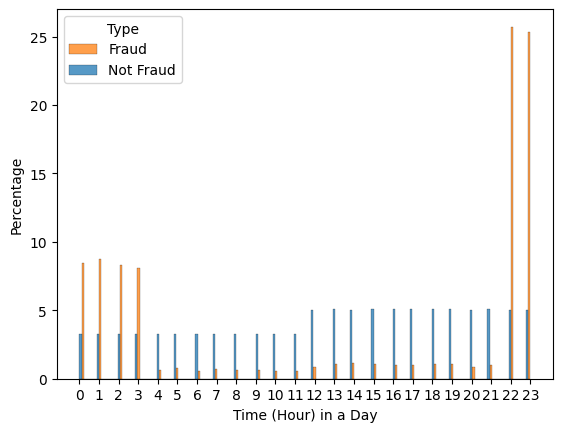

In [ ]:
# Time in the day vs Fraud

df['hour']=pd.to_datetime(df['trans_date_trans_time']).dt.hour
dftest['hour']=pd.to_datetime(dftest['trans_date_trans_time']).dt.hour

ax=sns.histplot(data=df, x="hour", hue="is_fraud", common_norm=False,stat='percent',multiple='dodge')
ax.set_ylabel('Percentage')
ax.set_xlabel('Time (Hour) in a Day')
plt.xticks(np.arange(0,24,1))
plt.legend(title='Type', labels=['Fraud', 'Not Fraud'])

Fraudulent payments happen disproportionately around midnight when most people are asleep.

/tmp/ipykernel_4147/2196492473.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['',"Mon","Tue","Wed","Thu","Fri","Sat","Sun"])


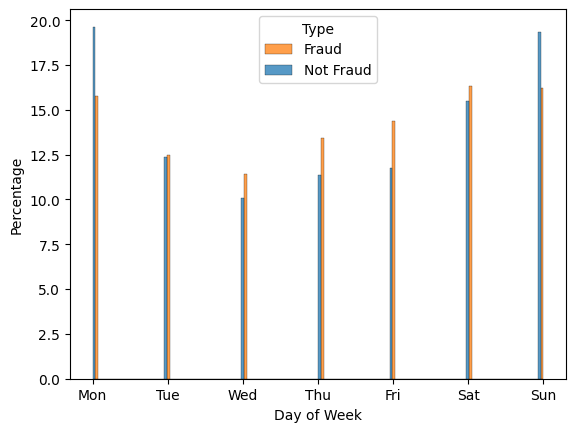

In [ ]:
# Day of week vs Fraud

df['day']=pd.to_datetime(df['trans_date_trans_time']).dt.dayofweek
dftest['day']=pd.to_datetime(dftest['trans_date_trans_time']).dt.dayofweek

ax=sns.histplot(data=df, x="day", hue="is_fraud", common_norm=False,stat='percent',multiple='dodge')
ax.set_xticklabels(['',"Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
ax.set_ylabel('Percentage')
ax.set_xlabel('Day of Week')
plt.legend(title='Type', labels=['Fraud', 'Not Fraud'])

Fraudulent transactions tend to happen throughout the week

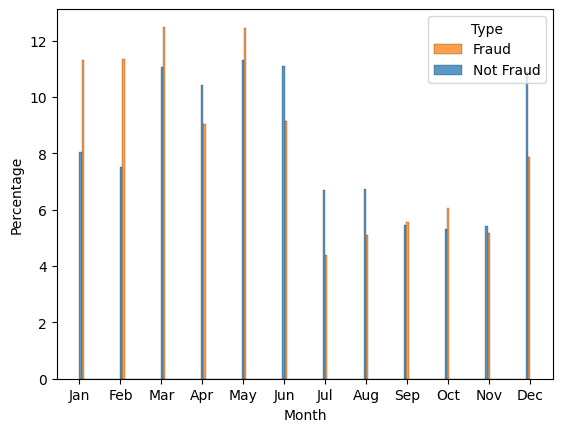

In [ ]:
# Month vs Fraud

df['month']=pd.to_datetime(df['trans_date_trans_time']).dt.month
dftest['month']=pd.to_datetime(dftest['trans_date_trans_time']).dt.month

ax=sns.histplot(data=df, x="month", hue="is_fraud", common_norm=False,stat='percent',multiple='dodge')
ax.set_ylabel('Percentage')
ax.set_xlabel('Month')
plt.xticks(np.arange(1,13,1))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul",'Aug','Sep','Oct','Nov','Dec'])
plt.legend(title='Type', labels=['Fraud', 'Not Fraud'])

Fraudulent transactions are crowded between Jan and June

<Axes: >

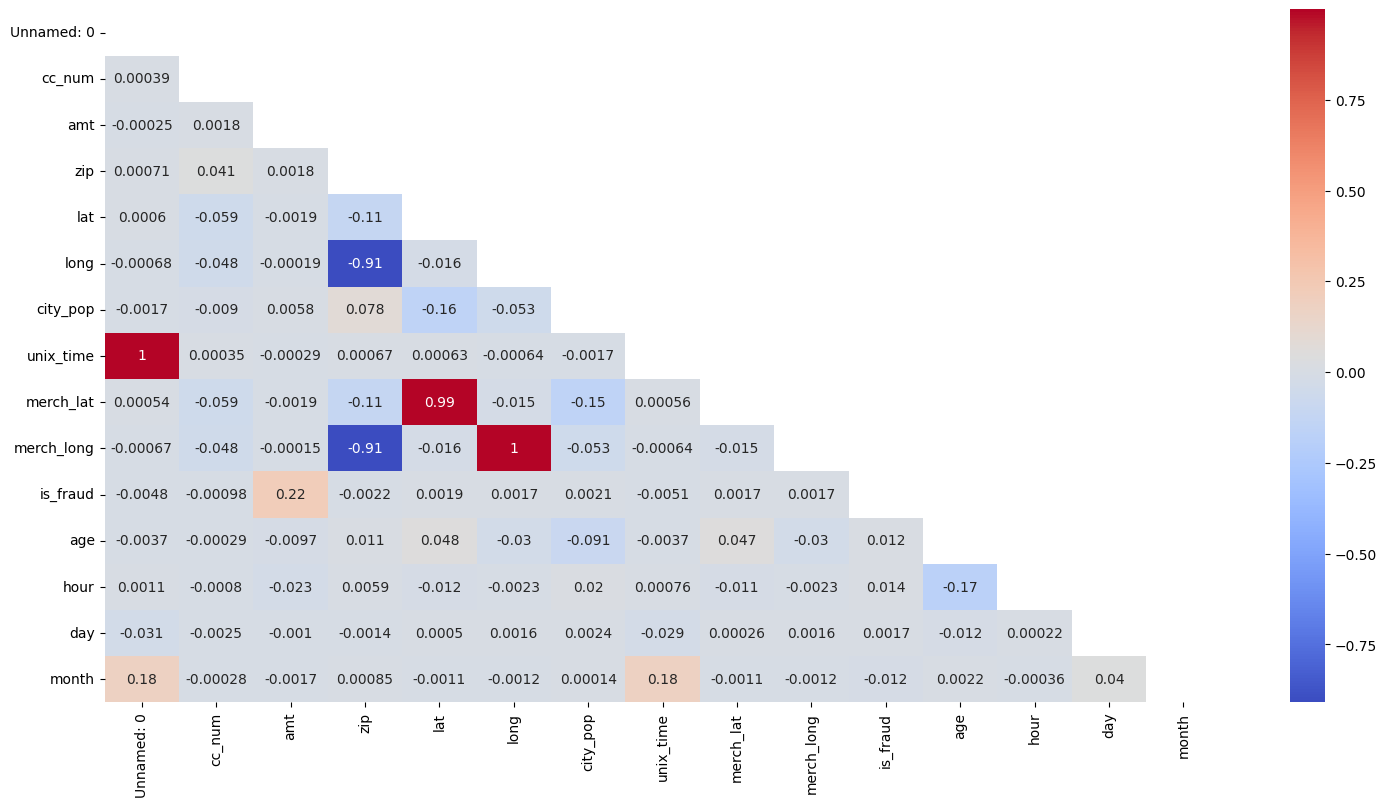

In [ ]:
# Correlation Matrix

%matplotlib inline
fig = plt.figure(figsize=(18,9))
# Select only numeric columns for correlation calculation
numeric_df = df.select_dtypes(include=np.number)
mask = np.triu(np.ones_like(numeric_df.corr()))
sns.heatmap(numeric_df.corr(), mask=mask, cmap='coolwarm', annot=True)

# Q3. Preprocessing

In [ ]:
# Remove all Personally Identifiable Information (PII)

df = df.drop(columns=['Unnamed: 0','cc_num','first','last','trans_num','street', 'city','state','zip', 'dob'])
dftest = dftest.drop(columns=['Unnamed: 0','cc_num','first','last','trans_num','street', 'city','state','zip', 'dob'])
df

,trans_date_trans_time,merchant,category,amt,gender,lat,long,city_pop,job,unix_time,merch_lat,merch_long,is_fraud,age,hour,day,month
0,2019-01-01 00:00:18,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,36.0788,-81.1781,3495,"Psychologist, counselling",1325376018,36.011293,-82.048315,0,38,0,1,1
1,2019-01-01 00:00:44,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,48.8878,-118.2105,149,Special educational needs teacher,1325376044,49.159047,-118.186462,0,48,0,1,1
2,2019-01-01 00:00:51,fraud_Lind-Buckridge,entertainment,220.11,M,42.1808,-112.2620,4154,Nature conservation officer,1325376051,43.150704,-112.154481,0,64,0,1,1
3,2019-01-01 00:01:16,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,46.2306,-112.1138,1939,Patent attorney,1325376076,47.034331,-112.561071,0,59,0,1,1
4,2019-01-01 00:03:06,fraud_Keeling-Crist,misc_pos,41.96,M,38.4207,-79.4629,99,Dance movement psychotherapist,1325376186,38.674999,-78.632459,0,40,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,2020-06-21 12:12:08,fraud_Reichel Inc,entertainment,15.56,M,37.7175,-112.4777,258,Geoscientist,1371816728,36.841266,-111.690765,0,65,12,6,6
1296671,2020-06-21 12:12:19,fraud_Abernathy and Sons,food_dining,51.70,M,39.2667,-77.5101,100,"Production assistant, television",1371816739,38.906881,-78.246528,0,47,12,6,6
1296672,2020-06-21 12:12:32,fraud_Stiedemann Ltd,food_dining,105.93,M,32.9396,-105.8189,899,Naval architect,1371816752,33.619513,-105.130529,0,59,12,6,6
1296673,2020-06-21 12:13:36,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,M,43.3526,-102.5411,1126,Volunteer coordinator,1371816816,42.788940,-103.241160,0,46,12,6,6


All columns with raw PII data are dropped.

---



In [ ]:
df.duplicated().sum()

np.int64(0)

The dataset shows zero duplicate entries.

In [ ]:
# Dropping original columns

df = df.drop(columns= ['trans_date_trans_time'])

dftest = dftest.drop(columns= ['trans_date_trans_time'])

df

,merchant,category,amt,gender,lat,long,city_pop,job,unix_time,merch_lat,merch_long,is_fraud,age,hour,day,month
0,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,36.0788,-81.1781,3495,"Psychologist, counselling",1325376018,36.011293,-82.048315,0,38,0,1,1
1,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,48.8878,-118.2105,149,Special educational needs teacher,1325376044,49.159047,-118.186462,0,48,0,1,1
2,fraud_Lind-Buckridge,entertainment,220.11,M,42.1808,-112.2620,4154,Nature conservation officer,1325376051,43.150704,-112.154481,0,64,0,1,1
3,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,46.2306,-112.1138,1939,Patent attorney,1325376076,47.034331,-112.561071,0,59,0,1,1
4,fraud_Keeling-Crist,misc_pos,41.96,M,38.4207,-79.4629,99,Dance movement psychotherapist,1325376186,38.674999,-78.632459,0,40,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,fraud_Reichel Inc,entertainment,15.56,M,37.7175,-112.4777,258,Geoscientist,1371816728,36.841266,-111.690765,0,65,12,6,6
1296671,fraud_Abernathy and Sons,food_dining,51.70,M,39.2667,-77.5101,100,"Production assistant, television",1371816739,38.906881,-78.246528,0,47,12,6,6
1296672,fraud_Stiedemann Ltd,food_dining,105.93,M,32.9396,-105.8189,899,Naval architect,1371816752,33.619513,-105.130529,0,59,12,6,6
1296673,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,M,43.3526,-102.5411,1126,Volunteer coordinator,1371816816,42.788940,-103.241160,0,46,12,6,6


### Distance calculation
The dataset provides us with locations in terms of coordinates. In order to calculate the distance, we use the Haversine function to find the distance between the merchants and the location of the transactions





In [ ]:
# Distance calculation when given coordinates

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth's radius in kilometers

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dist_lat = lat2 - lat1
    dist_lon = lon2 - lon1

    a = np.sin(dist_lat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dist_lon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

In [ ]:
df['distance_km'] = haversine(df['lat'], df['long'], df['merch_lat'], df['merch_long'])

dftest['distance_km'] = haversine(dftest['lat'], dftest['long'], dftest['merch_lat'], dftest['merch_long'])

df['distance_km'].head()


,distance_km
0,78.597568
1,30.212176
2,108.206083
3,95.673231
4,77.556744


In [ ]:
# Dropping original columns

df = df.drop(columns=['lat','long','merch_lat','merch_long'])

dftest = dftest.drop(columns=['lat','long','merch_lat','merch_long'])

df

,merchant,category,amt,gender,city_pop,job,unix_time,is_fraud,age,hour,day,month,distance_km
0,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,3495,"Psychologist, counselling",1325376018,0,38,0,1,1,78.597568
1,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,149,Special educational needs teacher,1325376044,0,48,0,1,1,30.212176
2,fraud_Lind-Buckridge,entertainment,220.11,M,4154,Nature conservation officer,1325376051,0,64,0,1,1,108.206083
3,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,1939,Patent attorney,1325376076,0,59,0,1,1,95.673231
4,fraud_Keeling-Crist,misc_pos,41.96,M,99,Dance movement psychotherapist,1325376186,0,40,0,1,1,77.556744
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,fraud_Reichel Inc,entertainment,15.56,M,258,Geoscientist,1371816728,0,65,12,6,6,119.752136
1296671,fraud_Abernathy and Sons,food_dining,51.70,M,100,"Production assistant, television",1371816739,0,47,12,6,6,75.104085
1296672,fraud_Stiedemann Ltd,food_dining,105.93,M,899,Naval architect,1371816752,0,59,12,6,6,99.047734
1296673,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,M,1126,Volunteer coordinator,1371816816,0,46,12,6,6,84.627652


## Feature Encoding and Scaling

### Target Encoding, One Hot Encoding and Scaling

Target encoding is applied to the "merchants" and the "jobs" columns. This allows to convert these columns into numerical values that the model can read. One hot encoding is applied to the "category","gender","day_of_week" to convert these columns into numerical data. Lastly we scale all the numerical data.

In [ ]:
# Applying target encoding on merchants

merchant_encoding = df.groupby('merchant')['is_fraud'].mean()
df['merchant_encoded'] = df['merchant'].map(merchant_encoding)

merchant_encoding = dftest.groupby('merchant')['is_fraud'].mean()
dftest['merchant_encoded'] = dftest['merchant'].map(merchant_encoding)

df

,merchant,category,amt,gender,city_pop,job,unix_time,is_fraud,age,hour,day,month,distance_km,merchant_encoded
0,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,3495,"Psychologist, counselling",1325376018,0,38,0,1,1,78.597568,0.014207
1,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,149,Special educational needs teacher,1325376044,0,48,0,1,1,30.212176,0.010787
2,fraud_Lind-Buckridge,entertainment,220.11,M,4154,Nature conservation officer,1325376051,0,64,0,1,1,108.206083,0.002111
3,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,1939,Patent attorney,1325376076,0,59,0,1,1,95.673231,0.003444
4,fraud_Keeling-Crist,misc_pos,41.96,M,99,Dance movement psychotherapist,1325376186,0,40,0,1,1,77.556744,0.003769
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,fraud_Reichel Inc,entertainment,15.56,M,258,Geoscientist,1371816728,0,65,12,6,6,119.752136,0.002622
1296671,fraud_Abernathy and Sons,food_dining,51.70,M,100,"Production assistant, television",1371816739,0,47,12,6,6,75.104085,0.002284
1296672,fraud_Stiedemann Ltd,food_dining,105.93,M,899,Naval architect,1371816752,0,59,12,6,6,99.047734,0.001079
1296673,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,M,1126,Volunteer coordinator,1371816816,0,46,12,6,6,84.627652,0.002094


In [ ]:
# Applying target encoding on jobs

job_encoding = df.groupby('job')['is_fraud'].mean()
df['job_encoding'] = df['job'].map(job_encoding)

job_encoding = dftest.groupby('job')['is_fraud'].mean()
dftest['job_encoding'] = dftest['job'].map(job_encoding)

df

,merchant,category,amt,gender,city_pop,job,unix_time,is_fraud,age,hour,day,month,distance_km,merchant_encoded,job_encoding
0,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,3495,"Psychologist, counselling",1325376018,0,38,0,1,1,78.597568,0.014207,0.001693
1,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,149,Special educational needs teacher,1325376044,0,48,0,1,1,30.212176,0.010787,0.002157
2,fraud_Lind-Buckridge,entertainment,220.11,M,4154,Nature conservation officer,1325376051,0,64,0,1,1,108.206083,0.002111,0.015656
3,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,1939,Patent attorney,1325376076,0,59,0,1,1,95.673231,0.003444,0.007905
4,fraud_Keeling-Crist,misc_pos,41.96,M,99,Dance movement psychotherapist,1325376186,0,40,0,1,1,77.556744,0.003769,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,fraud_Reichel Inc,entertainment,15.56,M,258,Geoscientist,1371816728,0,65,12,6,6,119.752136,0.002622,0.005338
1296671,fraud_Abernathy and Sons,food_dining,51.70,M,100,"Production assistant, television",1371816739,0,47,12,6,6,75.104085,0.002284,0.015066
1296672,fraud_Stiedemann Ltd,food_dining,105.93,M,899,Naval architect,1371816752,0,59,12,6,6,99.047734,0.001079,0.006103
1296673,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,M,1126,Volunteer coordinator,1371816816,0,46,12,6,6,84.627652,0.002094,0.003953


In [ ]:
# Dropping original columns

df = df.drop(columns =['merchant','job'])

dftest = dftest.drop(columns =['merchant','job'])

df

,category,amt,gender,city_pop,unix_time,is_fraud,age,hour,day,month,distance_km,merchant_encoded,job_encoding
0,misc_net,4.97,F,3495,1325376018,0,38,0,1,1,78.597568,0.014207,0.001693
1,grocery_pos,107.23,F,149,1325376044,0,48,0,1,1,30.212176,0.010787,0.002157
2,entertainment,220.11,M,4154,1325376051,0,64,0,1,1,108.206083,0.002111,0.015656
3,gas_transport,45.00,M,1939,1325376076,0,59,0,1,1,95.673231,0.003444,0.007905
4,misc_pos,41.96,M,99,1325376186,0,40,0,1,1,77.556744,0.003769,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,entertainment,15.56,M,258,1371816728,0,65,12,6,6,119.752136,0.002622,0.005338
1296671,food_dining,51.70,M,100,1371816739,0,47,12,6,6,75.104085,0.002284,0.015066
1296672,food_dining,105.93,M,899,1371816752,0,59,12,6,6,99.047734,0.001079,0.006103
1296673,food_dining,74.90,M,1126,1371816816,0,46,12,6,6,84.627652,0.002094,0.003953


In [ ]:
# Splitting the dataset into numerical and catergorical columns

numerical_cols = ['amt', 'distance_km', 'city_pop', 'unix_time','hour']

categorical_cols = ['category','gender','day']

In [ ]:
# Isolate the columns to be standard scaled
scale_cols = [col for col in numerical_cols if col != 'amt']

# Apply the stateless log transformation to 'amt' on BOTH sets
df['amt_log'] = np.log1p(df['amt'])
dftest['amt_log'] = np.log1p(dftest['amt'])

# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the training data (for the non-amt numerical columns)
df[scale_cols] = scaler.fit_transform(df[scale_cols])

# Transform the test data using the TRAIN parameters
dftest[scale_cols] = scaler.transform(dftest[scale_cols])

# Drop the original raw 'amt' column so your model only sees 'amt_log'
df = df.drop(columns=['amt'])
dftest = dftest.drop(columns=['amt'])

We scale down all other numerical columns such that mean is 0 and standard deviation is 1. For amt column, we use log transformation since there are a lot of small transactions (USD 5, 10, 15) and fewer large transaction (USD 100)

In [ ]:
# Applying one hot encoding to categorical columns

df = pd.get_dummies(df, columns = categorical_cols)

dftest = pd.get_dummies(dftest, columns = categorical_cols)

df

,city_pop,unix_time,is_fraud,age,hour,month,distance_km,merchant_encoded,job_encoding,amt_log,...,category_travel,gender_F,gender_M,day_0,day_1,day_2,day_3,day_4,day_5,day_6
0,-0.282589,-1.858664,0,38,-1.878145,1,0.085274,0.014207,0.001693,1.786747,...,False,True,False,False,True,False,False,False,False,False
1,-0.293670,-1.858662,0,48,-1.878145,1,-1.576488,0.010787,0.002157,4.684259,...,False,True,False,False,True,False,False,False,False,False
2,-0.280406,-1.858662,0,64,-1.878145,1,1.102157,0.002111,0.015656,5.398660,...,False,False,True,False,True,False,False,False,False,False
3,-0.287742,-1.858660,0,59,-1.878145,1,0.671726,0.003444,0.007905,3.828641,...,False,False,True,False,True,False,False,False,False,False
4,-0.293835,-1.858651,0,40,-1.878145,1,0.049528,0.003769,0.000000,3.760269,...,False,False,True,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,-0.293309,1.757855,0,65,-0.118052,6,1.498698,0.002622,0.005338,2.806990,...,False,False,True,False,False,False,False,False,False,True
1296671,-0.293832,1.757855,0,47,-0.118052,6,-0.034707,0.002284,0.015066,3.964615,...,False,False,True,False,False,False,False,False,False,True
1296672,-0.291186,1.757856,0,59,-0.118052,6,0.787620,0.001079,0.006103,4.672174,...,False,False,True,False,False,False,False,False,False,True
1296673,-0.290434,1.757861,0,46,-0.118052,6,0.292373,0.002094,0.003953,4.329417,...,False,False,True,False,False,False,False,False,False,True


## Input-Target split

In [ ]:
# Split data into input and target

X_train_full = df.drop(columns=["is_fraud"], inplace=False)
Y_train_full = df["is_fraud"]

X_test = dftest.drop(columns=["is_fraud"], inplace=False)
Y_test = dftest["is_fraud"]

# Split the training data to create the Validation set (20%)

X_train, X_val, Y_train, Y_val = train_test_split(
    X_train_full,
    Y_train_full,
    test_size=0.20,
    random_state=42,
    stratify=Y_train_full
)

In [ ]:
X_train

,city_pop,unix_time,age,hour,month,distance_km,merchant_encoded,job_encoding,amt_log,category_entertainment,...,category_travel,gender_F,gender_M,day_0,day_1,day_2,day_3,day_4,day_5,day_6
509059,-0.293935,-0.370807,35,-1.438122,8,-1.525906,0.001098,0.004183,3.964805,False,...,False,True,False,False,False,False,False,True,False,False
395295,-0.285798,-0.641979,56,0.908669,6,-0.046490,0.004934,0.008065,2.693275,True,...,False,True,False,False,False,False,False,False,True,False
536531,-0.293882,-0.307033,42,0.175297,8,0.439561,0.005197,0.006366,6.869285,False,...,False,True,False,False,False,False,False,False,False,True
271001,-0.293739,-0.957784,60,1.202018,5,-0.572575,0.004063,0.009728,3.799526,False,...,False,False,True,True,False,False,False,False,False,False
532788,-0.271965,-0.313886,28,0.175297,8,1.286426,0.001634,0.006103,3.528711,True,...,False,True,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125527,0.448514,-1.388496,41,1.202018,3,0.960445,0.002160,0.004069,3.030134,True,...,False,True,False,False,False,False,False,False,False,True
150047,-0.288189,-1.312240,52,-1.144773,3,-0.238712,0.007745,0.002810,4.823904,False,...,False,False,True,False,False,False,False,True,False,False
1151888,-0.293458,1.376022,54,0.761994,4,-0.239934,0.002284,0.002157,4.189352,False,...,False,True,False,False,False,False,False,False,True,False
547306,-0.192261,-0.280039,33,0.175297,8,0.045570,0.000455,0.005846,3.545298,False,...,False,False,True,False,False,False,True,False,False,False


In [ ]:
X_test

,city_pop,unix_time,age,hour,month,distance_km,merchant_encoded,job_encoding,amt_log,category_entertainment,...,category_travel,gender_F,gender_M,day_0,day_1,day_2,day_3,day_4,day_5,day_6
0,0.810291,1.757865,58,-0.118052,6,-1.770558,0.004076,0.000000,1.350667,False,...,False,False,True,False,False,False,False,False,False,True
1,-0.293163,1.757866,36,-0.118052,6,0.989474,0.001274,0.000000,3.428813,False,...,False,True,False,False,False,False,False,False,False,True
2,-0.179922,1.757867,56,-0.118052,6,-0.585040,0.001325,0.005798,3.744314,False,...,False,True,False,False,False,False,False,False,False,True
3,-0.112789,1.757869,39,-0.118052,6,-1.662816,0.004219,0.015083,4.111693,False,...,False,False,True,False,False,False,False,False,False,True
4,-0.290434,1.757869,71,-0.118052,6,0.969211,0.002703,0.000000,1.432701,False,...,True,False,True,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555714,-0.292444,3.059721,60,1.495367,12,0.031305,0.002642,0.006474,3.801538,False,...,False,False,True,False,False,False,True,False,False,False
555715,-0.198987,3.059721,27,1.495367,12,0.822881,0.002982,0.000000,4.725971,False,...,False,False,True,False,False,False,True,False,False,False
555716,-0.281963,3.059721,45,1.495367,12,0.159517,0.002876,0.000000,4.475972,False,...,False,True,False,False,False,False,True,False,False,False
555717,-0.293736,3.059722,61,1.495367,12,-0.796149,0.000000,0.000000,2.196113,False,...,True,False,True,False,False,False,True,False,False,False


In [ ]:
X_train_full

,city_pop,unix_time,age,hour,month,distance_km,merchant_encoded,job_encoding,amt_log,category_entertainment,...,category_travel,gender_F,gender_M,day_0,day_1,day_2,day_3,day_4,day_5,day_6
0,-0.282589,-1.858664,38,-1.878145,1,0.085274,0.014207,0.001693,1.786747,False,...,False,True,False,False,True,False,False,False,False,False
1,-0.293670,-1.858662,48,-1.878145,1,-1.576488,0.010787,0.002157,4.684259,False,...,False,True,False,False,True,False,False,False,False,False
2,-0.280406,-1.858662,64,-1.878145,1,1.102157,0.002111,0.015656,5.398660,True,...,False,False,True,False,True,False,False,False,False,False
3,-0.287742,-1.858660,59,-1.878145,1,0.671726,0.003444,0.007905,3.828641,False,...,False,False,True,False,True,False,False,False,False,False
4,-0.293835,-1.858651,40,-1.878145,1,0.049528,0.003769,0.000000,3.760269,False,...,False,False,True,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,-0.293309,1.757855,65,-0.118052,6,1.498698,0.002622,0.005338,2.806990,True,...,False,False,True,False,False,False,False,False,False,True
1296671,-0.293832,1.757855,47,-0.118052,6,-0.034707,0.002284,0.015066,3.964615,False,...,False,False,True,False,False,False,False,False,False,True
1296672,-0.291186,1.757856,59,-0.118052,6,0.787620,0.001079,0.006103,4.672174,False,...,False,False,True,False,False,False,False,False,False,True
1296673,-0.290434,1.757861,46,-0.118052,6,0.292373,0.002094,0.003953,4.329417,False,...,False,False,True,False,False,False,False,False,False,True


Training, Validation and Testing all preprocessed and have 32 features

# Q4. Supervised Learning


## Logistic Regression with Class weights

In [ ]:
model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

model.fit(X_train, Y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
model.score(X_train, Y_train)

0.7982647926427208

### Evaluation

In [ ]:
Y_pred = model.predict(X_val)

print(confusion_matrix(Y_val, Y_pred))
print(classification_report(Y_val, Y_pred))

[[205802  52032]
 [   330   1171]]
              precision    recall  f1-score   support

           0       1.00      0.80      0.89    257834
           1       0.02      0.78      0.04      1501

    accuracy                           0.80    259335
   macro avg       0.51      0.79      0.46    259335
weighted avg       0.99      0.80      0.88    259335



## Logistic Regression with SMOTE

In [ ]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    Y_train
)

In [ ]:
model_smote = LogisticRegression(
    max_iter=5000,
    random_state=42
)

model_smote.fit(X_train_smote, y_train_smote)

LogisticRegression(max_iter=5000, random_state=42)

### Evaluation

In [ ]:
model.score(X_train_smote, y_train_smote)

0.7385640941110309

In [ ]:
Y_pred_smote = model_smote.predict(X_val)

print(confusion_matrix(Y_val, Y_pred_smote))
print(classification_report(Y_val, Y_pred_smote))

[[255173   2661]
 [   528    973]]
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    257834
           1       0.27      0.65      0.38      1501

    accuracy                           0.99    259335
   macro avg       0.63      0.82      0.69    259335
weighted avg       0.99      0.99      0.99    259335



### Adjusting Classification Threshold to Improve Precision

We can calculate the probabilities of the predictions from the SMOTE model and then adjust the classification threshold. By increasing the threshold for classifying a transaction as fraudulent, we aim to reduce false positives, thereby increasing precision.

In [ ]:
# Get predicted probabilities for the validation set using the SMOTE model
Y_pred_proba_smote = model_smote.predict_proba(X_val)[:, 1]

# Define a new threshold (e.g., 0.7, 0.8, or whatever makes sense)
# A higher threshold will lead to fewer predicted positives (fraud), potentially increasing precision.
new_threshold = 0.55

# Classify based on the new threshold
Y_pred_smote_adjusted = (Y_pred_proba_smote >= new_threshold).astype(int)

print(f"Classification Report with threshold = {new_threshold}:")
print(confusion_matrix(Y_val, Y_pred_smote_adjusted))
print(classification_report(Y_val, Y_pred_smote_adjusted))

Classification Report with threshold = 0.55:
[[255830   2004]
 [   603    898]]
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    257834
           1       0.31      0.60      0.41      1501

    accuracy                           0.99    259335
   macro avg       0.65      0.80      0.70    259335
weighted avg       0.99      0.99      0.99    259335



### Regularization
Fine-tuning the C parameter (Strength of L1/L2 penalty) to prevent the model from over-fitting to noisy "normal" transactions.


In [ ]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
best_val_score = -1
best_C = None

for C in C_values:
    model = LogisticRegression(C=C, penalty='l2', solver='lbfgs',
                               class_weight='balanced', random_state=42, max_iter=5000)
    model.fit(X_train, Y_train)
    Y_val_proba = model.predict_proba(X_val)[:, 1]
    val_auprc = average_precision_score(Y_val, Y_val_proba)
    print(f"C={C:5}  Validation AUPRC = {val_auprc:.4f}")
    if val_auprc > best_val_score:
        best_val_score = val_auprc
        best_C = C

print(f"Best C = {best_C} with AUPRC = {best_val_score:.4f}")

C=0.001  Validation AUPRC = 0.1940
C= 0.01  Validation AUPRC = 0.2044
C=  0.1  Validation AUPRC = 0.2216
C=    1  Validation AUPRC = 0.1956
C=   10  Validation AUPRC = 0.1663
C=  100  Validation AUPRC = 0.1633
Best C = 0.1 with AUPRC = 0.2216


### Evaluating the best regularized model (`C=0.1`)

Now, let's look at the performance of the model with the optimal C value on the validation set.

In [ ]:
# Re-instantiate the Logistic Regression model with the best C value
best_C_model = LogisticRegression(
    C=best_C,
    penalty='l2',
    solver='lbfgs',
    class_weight='balanced',
    random_state=42,
    max_iter=5000
)

# Train the model on the original (non-SMOTE) training data
best_C_model.fit(X_train, Y_train)

# Make predictions on the validation set
Y_pred_best_C = best_C_model.predict(X_val)

print(f"Confusion Matrix for Logistic Regression with C = {best_C}:")
print(confusion_matrix(Y_val, Y_pred_best_C))
print(f"\nClassification Report for Logistic Regression with C = {best_C}:")
print(classification_report(Y_val, Y_pred_best_C))

Confusion Matrix for Logistic Regression with C = 0.1:
[[201240  56594]
 [   346   1155]]

Classification Report for Logistic Regression with C = 0.1:
              precision    recall  f1-score   support

           0       1.00      0.78      0.88    257834
           1       0.02      0.77      0.04      1501

    accuracy                           0.78    259335
   macro avg       0.51      0.77      0.46    259335
weighted avg       0.99      0.78      0.87    259335



### Regularization with SMOTE Data

We look to fine-tune the `C` parameter for the Logistic Regression model using the SMOTE-resampled training data to see if we can achieve even better performance, again evaluating with AUPRC on the original validation set.

In [ ]:
C_values_smote = [0.001, 0.01, 0.1, 1, 10, 100]
best_val_score_smote = -1
best_C_smote = None

print("Finding best C for Logistic Regression with SMOTE training data:")
for C_smote in C_values_smote:
    model_smote_tuned = LogisticRegression(C=C_smote, penalty='l2', solver='lbfgs',
                                         random_state=42, max_iter=5000)
    model_smote_tuned.fit(X_train_smote, y_train_smote)
    Y_val_proba_smote = model_smote_tuned.predict_proba(X_val)[:, 1]
    val_auprc_smote = average_precision_score(Y_val, Y_val_proba_smote)
    print(f"C={C_smote:5}  Validation AUPRC = {val_auprc_smote:.4f}")
    if val_auprc_smote > best_val_score_smote:
        best_val_score_smote = val_auprc_smote
        best_C_smote = C_smote

print(f"\nBest C for SMOTE model = {best_C_smote} with AUPRC = {best_val_score_smote:.4f}")

Finding best C for Logistic Regression with SMOTE training data:
C=0.001  Validation AUPRC = 0.2555
C= 0.01  Validation AUPRC = 0.2988
C=  0.1  Validation AUPRC = 0.3329
C=    1  Validation AUPRC = 0.3517
C=   10  Validation AUPRC = 0.3573
C=  100  Validation AUPRC = 0.3106

Best C for SMOTE model = 10 with AUPRC = 0.3573


### Evaluating the best regularized model with SMOTE (`C=10`)

 Evaluating the performance of the Logistic Regression model using the optimal `C` value (`10`) found when training on SMOTE data.

In [ ]:
# Re-instantiate the Logistic Regression model with the best C value for SMOTE
best_C_smote_model = LogisticRegression(
    C=best_C_smote,
    penalty='l2',
    solver='lbfgs',
    random_state=42,
    max_iter=5000
)

# Train the model on the SMOTE training data
best_C_smote_model.fit(X_train_smote, y_train_smote)

# Make predictions on the original validation set
Y_pred_best_C_smote = best_C_smote_model.predict(X_val)

print(f"Confusion Matrix for Logistic Regression with SMOTE and C = {best_C_smote}:")
print(confusion_matrix(Y_val, Y_pred_best_C_smote))
print(f"\nClassification Report for Logistic Regression with SMOTE and C = {best_C_smote}:")
print(classification_report(Y_val, Y_pred_best_C_smote))

Confusion Matrix for Logistic Regression with SMOTE and C = 10:
[[255261   2573]
 [   518    983]]

Classification Report for Logistic Regression with SMOTE and C = 10:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    257834
           1       0.28      0.65      0.39      1501

    accuracy                           0.99    259335
   macro avg       0.64      0.82      0.69    259335
weighted avg       0.99      0.99      0.99    259335



### Evaluating the Best Deployable Model on the Test Set

We assess the performance of our chosen deployable model (Logistic Regression trained with SMOTE and an optimized `C=10`, with a classification threshold of `0.55`) on the completely unseen `X_test` data.

In [ ]:
# Re-instantiate the best SMOTE model with the optimal C (best_C_smote)
best_deployable_model = LogisticRegression(
    C=best_C_smote,
    penalty='l2',
    solver='lbfgs',
    random_state=42,
    max_iter=5000
)

# Train this model on the SMOTE-resampled training data
best_deployable_model.fit(X_train_smote, y_train_smote)

# Get predicted probabilities for the test set
Y_pred_proba_test = best_deployable_model.predict_proba(X_test)[:, 1]

# Apply the chosen classification threshold
final_threshold = 0.55 # Based on previous adjustments for better precision
Y_pred_test_adjusted = (Y_pred_proba_test >= final_threshold).astype(int)

print(f"Confusion Matrix for Best Deployable Model (SMOTE C={best_C_smote}, Threshold={final_threshold}):")
print(confusion_matrix(Y_test, Y_pred_test_adjusted))
print(f"\nClassification Report for Best Deployable Model (SMOTE C={best_C_smote}, Threshold={final_threshold}):")
print(classification_report(Y_test, Y_pred_test_adjusted))

Confusion Matrix for Best Deployable Model (SMOTE C=10, Threshold=0.55):
[[551045   2529]
 [   995   1150]]

Classification Report for Best Deployable Model (SMOTE C=10, Threshold=0.55):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.31      0.54      0.39      2145

    accuracy                           0.99    555719
   macro avg       0.66      0.77      0.70    555719
weighted avg       1.00      0.99      0.99    555719



### Confusion Matrix Heatmap for Best Deployable Model on Test Set

 Visualizing the confusion matrix to better understand the model's performance on the test data.

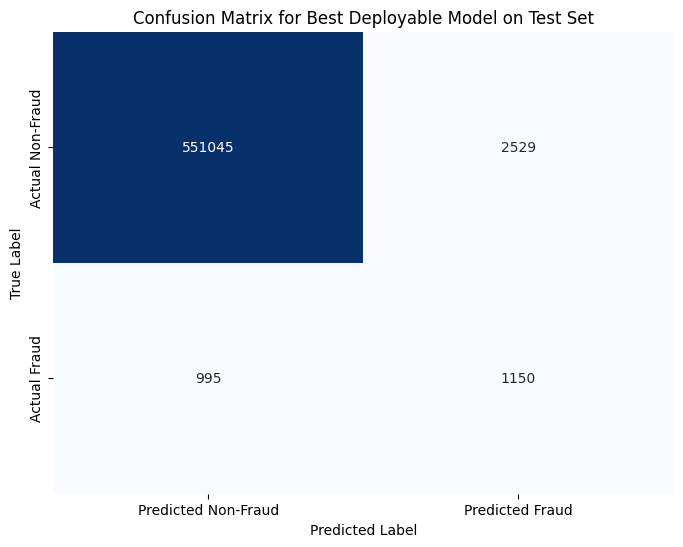

In [ ]:
cm = confusion_matrix(Y_test, Y_pred_test_adjusted)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Non-Fraud', 'Predicted Fraud'],
            yticklabels=['Actual Non-Fraud', 'Actual Fraud'])
plt.title('Confusion Matrix for Best Deployable Model on Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Precision-Recall Curve

The Precision-Recall curve is particularly useful for evaluating models on imbalanced datasets, as it highlights the trade-off between precision and recall for the positive class (fraud).

### Combined Visualization of Hyperparameter Tuning: Impact of Regularization (C) on AUPRC

This combined plot clearly illustrates the validation AUPRC performance for both the `class_weight='balanced'` and SMOTE-trained Logistic Regression models across different regularization strengths (`C`).

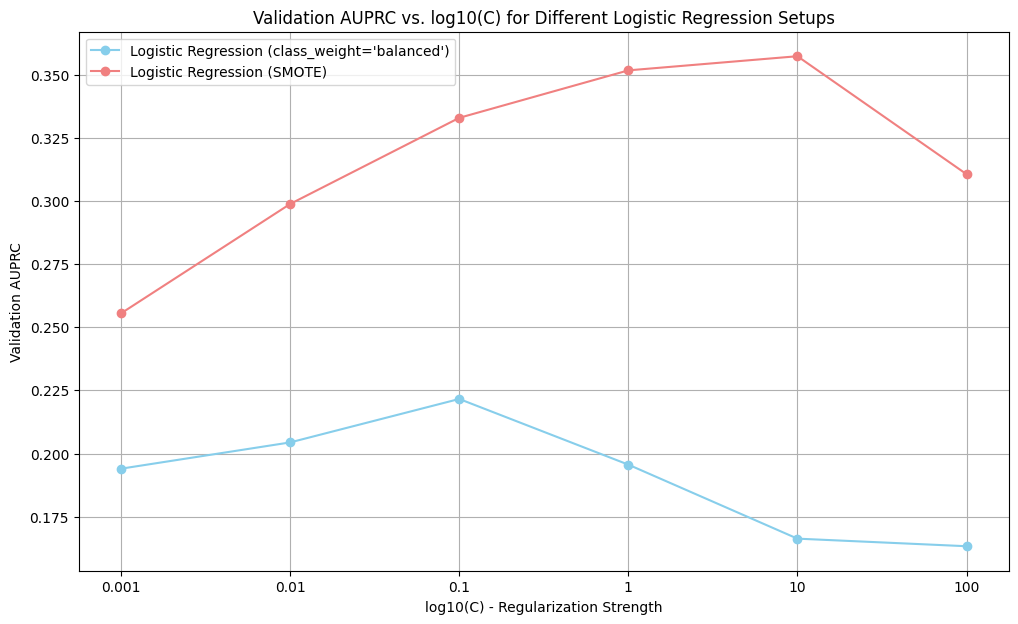

In [ ]:
plt.figure(figsize=(12, 7))
plt.plot(np.log10(C_values), val_auprc_balanced, marker='o', linestyle='-', color='skyblue', label='Logistic Regression (class_weight=\'balanced\')')
plt.plot(np.log10(C_values_smote), val_auprc_smote, marker='o', linestyle='-', color='lightcoral', label='Logistic Regression (SMOTE)')

plt.title('Validation AUPRC vs. log10(C) for Different Logistic Regression Setups')
plt.xlabel('log10(C) - Regularization Strength')
plt.ylabel('Validation AUPRC')
plt.xticks(np.log10(C_values), labels=[str(c) for c in C_values])
plt.grid(True)
plt.legend()
plt.show()

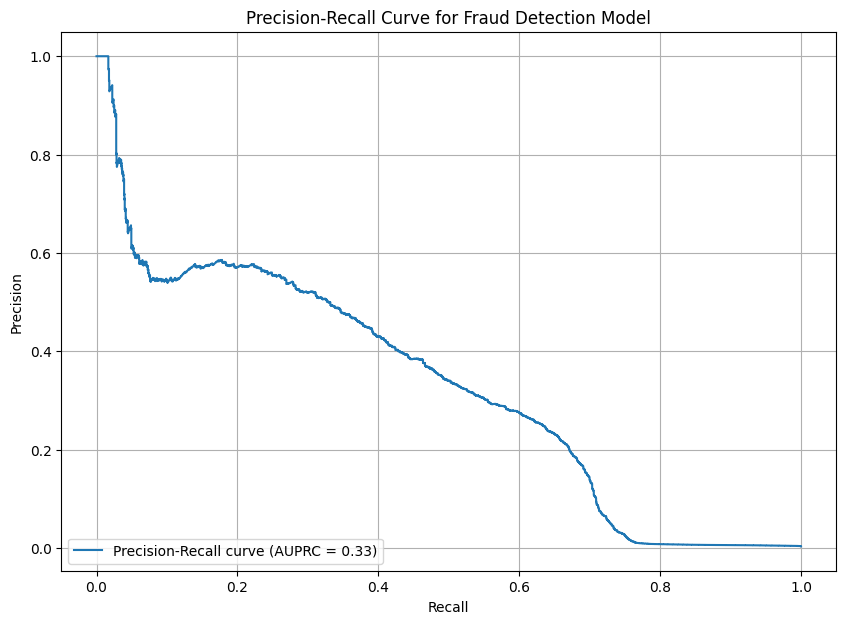

Area Under the Precision-Recall Curve (AUPRC): 0.3279


In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Get precision, recall, and thresholds from the prediction probabilities
precision, recall, thresholds = precision_recall_curve(Y_test, Y_pred_proba_test)

# Calculate Area Under the Precision-Recall Curve (AUPRC)
auprc = average_precision_score(Y_test, Y_pred_proba_test)

plt.figure(figsize=(10, 7))
plt.plot(recall, precision, label=f'Precision-Recall curve (AUPRC = {auprc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Fraud Detection Model')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

print(f"Area Under the Precision-Recall Curve (AUPRC): {auprc:.4f}")

### Area Under the Receiver Operating Characteristic (AUROC) Curve

While AUPRC is great for imbalanced datasets, AUROC is also a commonly used metric to evaluate the overall discriminative ability of a model. Let's calculate the AUROC for the deployable model on the test set.

### Analysis of the Best Deployable Model on the Validation Set

Let's re-examine the performance of our chosen deployable model (Logistic Regression trained with SMOTE and an optimized `C=10`, with a classification threshold of `0.55`) on the validation set.

In [ ]:
# Y_pred_proba_smote contains probabilities for X_val from best_C_smote_model
# final_threshold is already defined as 0.55

# Apply the chosen classification threshold to the validation probabilities
Y_pred_val_adjusted = (Y_pred_proba_smote >= final_threshold).astype(int)

print(f"Confusion Matrix for Best Deployable Model (SMOTE C={best_C_smote}, Threshold={final_threshold}) on Validation Set:")
print(confusion_matrix(Y_val, Y_pred_val_adjusted))
print(f"\nClassification Report for Best Deployable Model (SMOTE C={best_C_smote}, Threshold={final_threshold}) on Validation Set:")
print(classification_report(Y_val, Y_pred_val_adjusted))

Confusion Matrix for Best Deployable Model (SMOTE C=10, Threshold=0.55) on Validation Set:
[[255830   2004]
 [   603    898]]

Classification Report for Best Deployable Model (SMOTE C=10, Threshold=0.55) on Validation Set:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    257834
           1       0.31      0.60      0.41      1501

    accuracy                           0.99    259335
   macro avg       0.65      0.80      0.70    259335
weighted avg       0.99      0.99      0.99    259335



In [ ]:
# Calculate AUPRC for the deployable model on the validation set
val_auprc_deployable = average_precision_score(Y_val, Y_pred_proba_smote)

print(f"Area Under the Precision-Recall Curve (AUPRC) for the Deployable Model on Validation Set: {val_auprc_deployable:.4f}")

Area Under the Precision-Recall Curve (AUPRC) for the Deployable Model on Validation Set: 0.3517


In [ ]:
from sklearn.metrics import roc_auc_score

# Calculate AUROC for the deployable model on the test set
auroc = roc_auc_score(Y_test, Y_pred_proba_test)

print(f"Area Under the Receiver Operating Characteristic (AUROC): {auroc:.4f}")

Area Under the Receiver Operating Characteristic (AUROC): 0.8637
